In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
nav = pd.read_csv("../data/processed/clean_nav.csv")
perf = pd.read_csv("../data/processed/clean_performance.csv")
benchmark = pd.read_csv("../data/processed/clean_benchmark_indices.csv")
fund = pd.read_csv("../data/processed/clean_fund_master.csv")

In [3]:
nav['date'] = pd.to_datetime(nav['date'])
benchmark['date'] = pd.to_datetime(benchmark['date'])

In [4]:
print("NAV shape:", nav.shape)
print("Benchmark shape:", benchmark.shape)

NAV shape: (46000, 3)
Benchmark shape: (8050, 3)


In [5]:
nav = nav.sort_values(['amfi_code', 'date']).reset_index(drop=True)

In [7]:
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

In [8]:
nav_returns = nav.dropna(subset=['daily_return']).copy()

In [9]:
print(f"Shape: {nav_returns.shape}")

Shape: (45960, 4)


In [10]:
nav_returns.head()

,date,amfi_code,nav,daily_return
1,2022-01-04,100016,515.0971,-0.010306
2,2022-01-05,100016,521.7239,0.012865
3,2022-01-06,100016,515.7880,-0.011377
4,2022-01-07,100016,515.1639,-0.001210
5,2022-01-10,100016,510.7136,-0.008639


In [11]:
def annualised_return(returns):
    n = len(returns)
    return (1 + returns).prod() ** (252 / n) - 1

In [12]:
ann_returns = nav_returns.groupby('amfi_code')['daily_return'].apply(
    annualised_return).reset_index()
ann_returns.columns = ['amfi_code', 'annualised_return']

In [14]:
ann_returns = ann_returns.merge(fund[['amfi_code', 'scheme_name']], on='amfi_code', how='left')

In [15]:
print(ann_returns)

    amfi_code  annualised_return  \
0      100016           0.025435   
1      100025           0.042987   
2      100033           0.289279   
3      101206           0.226265   
4      101207           0.076502   
5      101208           0.062739   
6      102885           0.175404   
7      102886           0.011304   
8      102887           0.162055   
9      118632           0.231161   
10     118633           0.156614   
11     118634           0.157567   
12     118635           0.153571   
13     118636           0.051259   
14     119092           0.061381   
15     119093           0.076105   
16     119094           0.271025   
17     119095           0.014678   
18     119120           0.056773   
19     119551           0.247966   
20     119552           0.206968   
21     119598           0.311266   
22     119599           0.019818   
23     120503           0.180708   
24     120504           0.223935   
25     120505           0.315124   
26     120506           0.16

In [16]:
nav_returns.to_csv("../data/processed/returns_computed.csv", index=False)

In [17]:
print(nav_returns.shape)

(45960, 4)


In [18]:
def compute_cagr(group, years):
    end_date = group['date'].max()
    start_date = end_date - pd.DateOffset(years=years)
    
    filtered = group[group['date'] >= start_date]
    
    if len(filtered) < 2:
        return np.nan
    
    nav_start = filtered.iloc[0]['nav']
    nav_end = filtered.iloc[-1]['nav']
    n = years
    
    return (nav_end / nav_start) ** (1 / n) - 1

In [19]:
cagr_list = []

for code, group in nav.groupby('amfi_code'):
    cagr_1yr = compute_cagr(group, 1)
    cagr_3yr = compute_cagr(group, 3)
    cagr_5yr = compute_cagr(group, 5)
    
    cagr_list.append({
        'amfi_code': code,
        'cagr_1yr': round(cagr_1yr * 100, 2),
        'cagr_3yr': round(cagr_3yr * 100, 2),
        'cagr_5yr': round(cagr_5yr * 100, 2)
    })

cagr_df = pd.DataFrame(cagr_list)
cagr_df = cagr_df.merge(fund[['amfi_code', 'scheme_name', 'fund_house']], 
                         on='amfi_code', how='left')

print(cagr_df)

    amfi_code  cagr_1yr  cagr_3yr  cagr_5yr  \
0      100016     -2.22      1.29      2.32   
1      100025      3.70      3.92      3.91   
2      100033     53.23     32.44     26.07   
3      101206     47.92     28.97     20.44   
4      101207    -23.99     -4.15      6.95   
5      101208      7.24      6.32      5.71   
6      102885     20.21     19.67     15.88   
7      102886    -16.80     -0.77      1.03   
8      102887     13.58     25.56     14.68   
9      118632     33.98     22.65     20.88   
10     118633     25.54     21.09     14.19   
11     118634     15.81      8.01     14.27   
12     118635     22.49     20.01     13.91   
13     118636     10.45      4.06      4.66   
14     119092      1.61      0.53      5.58   
15     119093     19.77     20.82      6.92   
16     119094     22.26     35.11     24.45   
17     119095    -42.80    -11.71      1.34   
18     119120      5.52      5.84      5.16   
19     119551     60.44     30.46     22.38   
20     119552

In [20]:
cagr_df.to_csv("../data/processed/cagr_report.csv", index=False)

In [21]:
Rf = 0.065 / 252  

def compute_sharpe(returns):
    excess_returns = returns - Rf
    if returns.std() == 0:
        return np.nan
    return (excess_returns.mean() / returns.std()) * np.sqrt(252)

sharpe = nav_returns.groupby('amfi_code')['daily_return'].apply(
    compute_sharpe).reset_index()
sharpe.columns = ['amfi_code', 'sharpe_ratio']

sharpe = sharpe.merge(fund[['amfi_code', 'scheme_name', 'fund_house']], 
                       on='amfi_code', how='left')

sharpe['sharpe_ratio'] = sharpe['sharpe_ratio'].round(4)
print(sharpe)

    amfi_code  sharpe_ratio  \
0      100016       -0.2015   
1      100025       -0.5671   
2      100033        1.0937   
3      101206        1.0272   
4      101207        0.1627   
5      101208       -0.8156   
6      102885        0.8171   
7      102886       -0.2058   
8      102887        0.6195   
9      118632        1.0817   
10     118633        0.6452   
11     118634        0.4484   
12     118635        0.6649   
13     118636       -0.3566   
14     119092        0.0308   
15     119093        0.1296   
16     119094        0.9982   
17     119095       -0.0760   
18     119120       -0.2266   
19     119551        1.2083   
20     119552        0.9533   
21     119598        0.9453   
22     119599       -0.0572   
23     120503        0.7980   
24     120504        1.0265   
25     120505        1.1801   
26     120506        0.6489   
27     120507        0.4957   
28     120841        0.4943   
29     120842        0.0760   
30     120843        1.3067   
31     1

In [22]:
sharpe.to_csv("../data/processed/sharpe_values.csv", index=False)

In [23]:
def compute_sortino(returns):
    excess_returns = returns - Rf
    downside_returns = returns[returns < 0]
    
    if len(downside_returns) == 0:
        return np.nan
    
    downside_std = downside_returns.std() * np.sqrt(252)
    
    if downside_std == 0:
        return np.nan
    
    return (excess_returns.mean() * 252) / downside_std

sortino = nav_returns.groupby('amfi_code')['daily_return'].apply(
    compute_sortino).reset_index()
sortino.columns = ['amfi_code', 'sortino_ratio']

sortino = sortino.merge(fund[['amfi_code', 'scheme_name', 'fund_house']], 
                         on='amfi_code', how='left')

sortino['sortino_ratio'] = sortino['sortino_ratio'].round(4)
print(sortino)

    amfi_code  sortino_ratio  \
0      100016        -0.3510   
1      100025        -0.9418   
2      100033         1.8291   
3      101206         1.7996   
4      101207         0.2766   
5      101208        -1.6810   
6      102885         1.4357   
7      102886        -0.3472   
8      102887         1.0888   
9      118632         1.8501   
10     118633         1.1545   
11     118634         0.7460   
12     118635         1.1380   
13     118636        -0.6135   
14     119092         0.0526   
15     119093         0.2211   
16     119094         1.7038   
17     119095        -0.1282   
18     119120        -0.3768   
19     119551         2.1403   
20     119552         1.6098   
21     119598         1.6753   
22     119599        -0.0944   
23     120503         1.3379   
24     120504         1.8053   
25     120505         2.0294   
26     120506         1.0959   
27     120507         1.0521   
28     120841         0.8626   
29     120842         0.1247   
30     1

In [24]:
sortino.to_csv("../data/processed/sortino_values.csv", index=False)

In [28]:
nifty100 = benchmark[benchmark['index_name'] == 'NIFTY100'].copy()
nifty100 = nifty100.sort_values('date')
nifty100['benchmark_return'] = nifty100['close_value'].pct_change()
nifty100 = nifty100.dropna(subset=['benchmark_return'])

print("Nifty 100 shape:", nifty100.shape)
print(nifty100.head())

Nifty 100 shape: (1149, 4)
           date index_name  close_value  benchmark_return
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150
1155 2022-01-10   NIFTY100     17516.51         -0.008351


In [29]:
alpha_beta_list = []

for code, group in nav_returns.groupby('amfi_code'):
    # Merge fund returns with benchmark returns on date
    merged = group.merge(nifty100[['date', 'benchmark_return']], 
                         on='date', how='inner')
    
    if len(merged) < 30:
        continue
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        merged['benchmark_return'], 
        merged['daily_return']
    )
    
    alpha_beta_list.append({
        'amfi_code': code,
        'alpha': round(intercept * 252, 4),
        'beta': round(slope, 4),
        'r_squared': round(r_value ** 2, 4)
    })

alpha_beta_df = pd.DataFrame(alpha_beta_list)
alpha_beta_df = alpha_beta_df.merge(fund[['amfi_code', 'scheme_name', 'fund_house']], 
                                     on='amfi_code', how='left')

print(alpha_beta_df)

    amfi_code   alpha    beta  r_squared  \
0      100016  0.0375 -0.0583     0.0027   
1      100025  0.0428  0.0012     0.0000   
2      100033  0.2720  0.0051     0.0000   
3      101206  0.2140  0.0211     0.0003   
4      101207  0.1090 -0.0653     0.0011   
5      101208  0.0609  0.0003     0.0000   
6      102885  0.1705 -0.0195     0.0004   
7      102886  0.0290 -0.0421     0.0009   
8      102887  0.1621  0.0167     0.0002   
9      118632  0.2183 -0.0084     0.0001   
10     118633  0.1564 -0.0366     0.0011   
11     118634  0.1750  0.1035     0.0028   
12     118635  0.1514 -0.0014     0.0000   
13     118636  0.0507  0.0013     0.0000   
14     119092  0.0690  0.0097     0.0001   
15     119093  0.0823  0.0259     0.0006   
16     119094  0.2608 -0.0663     0.0019   
17     119095  0.0480 -0.0670     0.0012   
18     119120  0.0562 -0.0064     0.0004   
19     119551  0.2320 -0.0318     0.0009   
20     119552  0.1987 -0.0262     0.0006   
21     119598  0.3034 -0.0232   

In [30]:
alpha_beta_df.to_csv("../data/processed/alpha_beta.csv", index=False)

In [31]:
def compute_max_drawdown(group):
    rolling_max = group['nav'].cummax()
    drawdown = group['nav'] / rolling_max - 1
    max_dd = drawdown.min()
    worst_date = drawdown.idxmin()
    return pd.Series({
        'max_drawdown': round(max_dd * 100, 4),
        'worst_date': group.loc[worst_date, 'date'] if worst_date in group.index else np.nan
    })

max_dd_df = nav.groupby('amfi_code').apply(compute_max_drawdown).reset_index()

max_dd_df = max_dd_df.merge(fund[['amfi_code', 'scheme_name', 'fund_house']], 
                              on='amfi_code', how='left')

print(max_dd_df)

    amfi_code  max_drawdown worst_date  \
0      100016      -24.7344 2022-09-15   
1      100025       -4.3083 2023-07-28   
2      100033      -16.2172 2022-05-12   
3      101206      -11.2916 2023-07-05   
4      101207      -35.4469 2026-05-11   
5      101208       -0.1622 2023-09-12   
6      102885      -10.8599 2022-03-29   
7      102886      -28.0011 2026-04-27   
8      102887      -21.5398 2022-07-04   
9      118632      -17.4141 2024-07-19   
10     118633      -18.6297 2024-02-29   
11     118634      -23.3449 2026-02-20   
12     118635      -11.6506 2022-06-09   
13     118636       -8.3164 2024-02-09   
14     119092      -14.4016 2025-02-07   
15     119093      -21.7514 2023-05-22   
16     119094      -20.9609 2022-08-11   
17     119095      -51.6778 2026-05-11   
18     119120       -4.3287 2025-04-01   
19     119551      -15.0124 2024-02-05   
20     119552      -11.8035 2024-09-02   
21     119598      -28.7060 2025-05-14   
22     119599      -52.5742 2025-1

In [32]:
max_dd_df.to_csv("../data/processed/max_drawdown.csv", index=False)

In [33]:
scorecard = cagr_df[['amfi_code', 'scheme_name', 'fund_house', 'cagr_3yr']].copy()

In [34]:
scorecard = scorecard.merge(sharpe[['amfi_code', 'sharpe_ratio']], on='amfi_code', how='left')
scorecard = scorecard.merge(alpha_beta_df[['amfi_code', 'alpha']], on='amfi_code', how='left')
scorecard = scorecard.merge(max_dd_df[['amfi_code', 'max_drawdown']], on='amfi_code', how='left')
scorecard = scorecard.merge(fund[['amfi_code', 'expense_ratio_pct']], on='amfi_code', how='left')

In [35]:
print(scorecard.shape)

(40, 8)


In [36]:
scorecard.head()

,amfi_code,scheme_name,fund_house,cagr_3yr,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,1.29,-0.2015,0.0375,-24.7344,1.55
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,3.92,-0.5671,0.0428,-4.3083,0.56
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,32.44,1.0937,0.2720,-16.2172,1.38
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,28.97,1.0272,0.2140,-11.2916,1.60
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,-4.15,0.1627,0.1090,-35.4469,1.53


In [37]:
scorecard['rank_3yr_return'] = scorecard['cagr_3yr'].rank(ascending=True)
scorecard['rank_sharpe'] = scorecard['sharpe_ratio'].rank(ascending=True)
scorecard['rank_alpha'] = scorecard['alpha'].rank(ascending=True)
scorecard['rank_expense'] = scorecard['expense_ratio_pct'].rank(ascending=False)  # Lower is better
scorecard['rank_max_dd'] = scorecard['max_drawdown'].rank(ascending=False)  # Less negative is better

In [38]:
n = len(scorecard)
for col in ['rank_3yr_return', 'rank_sharpe', 'rank_alpha', 'rank_expense', 'rank_max_dd']:
    scorecard[col] = (scorecard[col] / n) * 100

In [39]:
scorecard['composite_score'] = (
    0.30 * scorecard['rank_3yr_return'] +
    0.25 * scorecard['rank_sharpe'] +
    0.20 * scorecard['rank_alpha'] +
    0.15 * scorecard['rank_expense'] +
    0.10 * scorecard['rank_max_dd']
)

In [40]:
scorecard['composite_score'] = scorecard['composite_score'].round(2)

In [41]:
scorecard = scorecard.sort_values('composite_score', ascending=False).reset_index(drop=True)

In [42]:
print(scorecard[['scheme_name', 'composite_score']].head(10))

                                         scheme_name  composite_score
0           ICICI Pru Midcap Fund - Regular - Growth            84.50
1                Axis Midcap Fund - Regular - Growth            80.75
2  HDFC Mid-Cap Opportunities Fund - Regular - Gr...            80.50
3      Mirae Asset Large Cap Fund - Regular - Growth            80.00
4             Kotak Flexicap Fund - Regular - Growth            78.25
5          ICICI Pru Bluechip Fund - Direct - Growth            75.75
6         SBI Small Cap Fund - Regular Plan - Growth            75.12
7              DSP Small Cap Fund - Regular - Growth            74.94
8      Mirae Asset Tax Saver Fund - Regular - Growth            73.94
9          SBI Bluechip Fund - Regular Plan - Growth            73.06


In [43]:
scorecard.to_csv("../data/processed/fund_scorecard.csv", index=False)

In [44]:
top5_codes = scorecard.head(5)['amfi_code'].tolist()
top5_names = scorecard.head(5).set_index('amfi_code')['scheme_name'].to_dict()

In [45]:
end_date = nav['date'].max()
start_date = end_date - pd.DateOffset(years=3)

In [47]:
top5_nav = nav[(nav['amfi_code'].isin(top5_codes)) & 
               (nav['date'] >= start_date)].copy()

In [48]:
def normalize(group):
    group['normalized'] = (group['nav'] / group['nav'].iloc[0]) * 100
    return group

In [49]:
top5_nav = top5_nav.groupby('amfi_code').apply(normalize).reset_index(drop=True)
top5_nav['scheme_name'] = top5_nav['amfi_code'].map(top5_names)

In [50]:
nifty50 = benchmark[(benchmark['index_name'] == 'NIFTY50') & 
                    (benchmark['date'] >= start_date)].copy()
nifty100 = benchmark[(benchmark['index_name'] == 'NIFTY100') & 
                     (benchmark['date'] >= start_date)].copy()

In [52]:
nifty50['normalized'] = (nifty50['close_value'] / nifty50['close_value'].iloc[0]) * 100
nifty100['normalized'] = (nifty100['close_value'] / nifty100['close_value'].iloc[0]) * 100

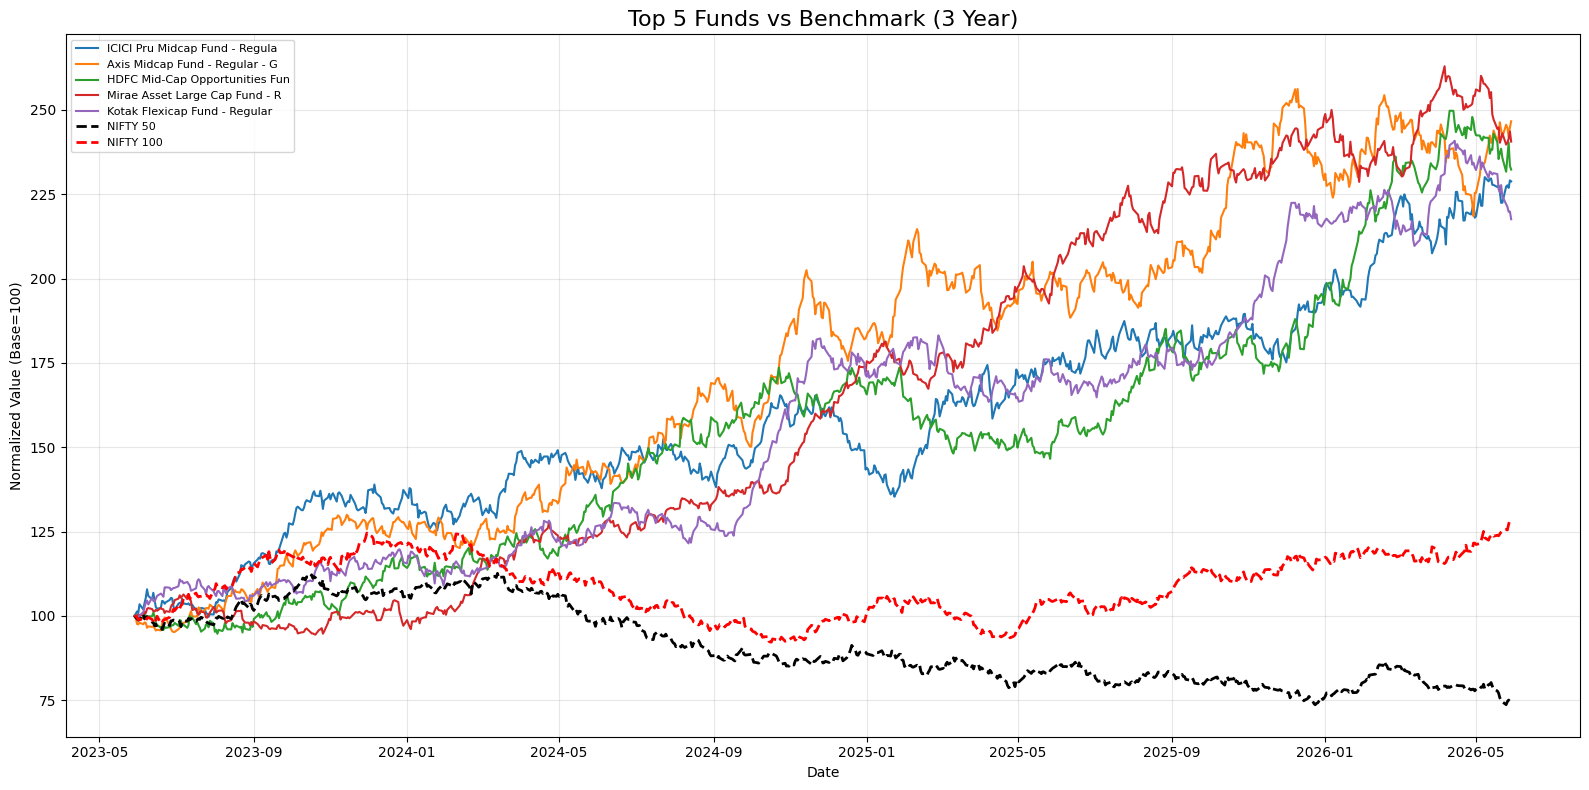

In [54]:
plt.figure(figsize=(16, 8))

for code in top5_codes:
    data = top5_nav[top5_nav['amfi_code'] == code]
    plt.plot(data['date'], data['normalized'], 
             linewidth=1.5, label=top5_names[code][:30])

plt.plot(nifty50['date'], nifty50['normalized'], 
         'k--', linewidth=2, label='NIFTY 50')
plt.plot(nifty100['date'], nifty100['normalized'], 
         'r--', linewidth=2, label='NIFTY 100')

plt.title('Top 5 Funds vs Benchmark (3 Year)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Normalized Value (Base=100)')
plt.legend(loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/charts/benchmark_chart.png")
plt.show()

In [55]:
tracking_errors = []

for code in top5_codes:
    fund_ret = nav_returns[nav_returns['amfi_code'] == code]['daily_return']
    bench_ret = nifty100[nifty100['date'].isin(
        nav_returns[nav_returns['amfi_code'] == code]['date'])]['benchmark_return'] \
        if 'benchmark_return' in nifty100.columns else nifty100['close_value'].pct_change()
    
    merged = nav_returns[nav_returns['amfi_code'] == code].merge(
        nifty100[['date', 'normalized']], on='date', how='inner')
    
    tracking_error = (merged['daily_return'] - merged['normalized'].pct_change()).std() * np.sqrt(252)
    
    tracking_errors.append({
        'scheme_name': top5_names[code],
        'tracking_error': round(tracking_error * 100, 4)
    })

te_df = pd.DataFrame(tracking_errors)
print(te_df)

                                         scheme_name  tracking_error
0           ICICI Pru Midcap Fund - Regular - Growth         23.2661
1                Axis Midcap Fund - Regular - Growth         23.9774
2  HDFC Mid-Cap Opportunities Fund - Regular - Gr...         22.4976
3      Mirae Asset Large Cap Fund - Regular - Growth         18.7974
4             Kotak Flexicap Fund - Regular - Growth         20.6540
